In [ ]:
import json
# TODO: Add human data comparison with LLMs results
from sotopia.database import AgentProfile, EnvironmentProfile

ImportError: cannot import name 'EpisodeProfile' from 'sotopia.database' (/data/user_data/wenkail/sotopia_diplomacy/diplomacy/sotopia-diplomacy/sotopia/database/__init__.py)

In [2]:
import os
import json

# 遍历得到epis_judgement目录下所有带v6且以.jsonl结尾的文件
v6_files = []
for fname in os.listdir('epis_judgement'):
    if 'v6' in fname and fname.endswith('.jsonl'):
        v6_files.append(fname)

# 用dict区分不同文件，key为文件名去掉.jsonl，value为内容（list of dicts）
v6_data_dict = {}
for fname in v6_files:
    key = fname[:-6] if fname.endswith('.jsonl') else fname
    file_path = os.path.join('epis_judgement', fname)
    file_data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    file_data.append(json.loads(line))
                except Exception as e:
                    print(f"Error parsing line in {fname}: {e}")
    v6_data_dict[key] = file_data


In [3]:
# 检查所有模型数据中共同的epi_pk
all_epi_pks_by_model = {}

# 先收集每个模型的所有epi_pk
for model_name, data_list in v6_data_dict.items():
    epi_pks = set()
    for item in data_list:
        if 'epi_pk' in item:
            epi_pks.add(item['epi_pk'])
    all_epi_pks_by_model[model_name] = epi_pks

# 找到所有模型都包含的epi_pk（交集）
if all_epi_pks_by_model:
    common_epi_pks = set.intersection(*all_epi_pks_by_model.values())
    print(f"所有模型都包含的epi_pk数量: {len(common_epi_pks)}")
    print(f"共同的epi_pk: {list(common_epi_pks)[:10]}...")  # 只显示前10个
    
    # 显示每个模型的epi_pk数量
    print("\n每个模型的epi_pk数量:")
    for model_name, epi_pks in all_epi_pks_by_model.items():
        print(f"{model_name}: {len(epi_pks)}")
else:
    print("没有找到任何模型数据")

v6_data_dict

所有模型都包含的epi_pk数量: 0
共同的epi_pk: []...

每个模型的epi_pk数量:
qwen3_8b_lora_finetune_format_v6_qwen3_8b_judgement: 354
qwen3_8b_finetune_format_v6_llama3_8b_judgement: 998
llama_8b_lora_finetune_format_v6_qwen3_8b_judgement: 376
llama_8b_finetune_format_v6_llama3_8b_judgement: 411
r1_distill_llama3_8b_finetune_format_v6_llama3_8b_judgement: 866


{'qwen3_8b_lora_finetune_format_v6_qwen3_8b_judgement': [{'epi_pk': '01JZ1KQX3MB1EFGH7SERCZHCVH',
   'turn_idx': 0,
   'epi_tag': 'qwen3_8b_lora_finetune_format_v6',
   'epi_messages': 'Turn #0: \n',
   '1gamemove.yes': 0,
   '2reasoning.yes': 0,
   '3rapport.yes': 0,
   '3a_apologies.yes': 0,
   '3a_compliment.yes': 0,
   '3a_personalthoughts.yes': 0,
   '3a_reassurance.yes': 0,
   '4shareinformation.yes': 0},
  {'epi_pk': '01JZ1KQX3MB1EFGH7SERCZHCVH',
   'turn_idx': 1,
   'epi_tag': 'qwen3_8b_lora_finetune_format_v6',
   'epi_messages': 'Turn #1: \n',
   '1gamemove.yes': 0,
   '2reasoning.yes': 0,
   '3rapport.yes': 0,
   '3a_apologies.yes': 0,
   '3a_compliment.yes': 0,
   '3a_personalthoughts.yes': 0,
   '3a_reassurance.yes': 0,
   '4shareinformation.yes': 0},
  {'epi_pk': '01JZ1H4NGAXZJ3P342X7M57F4G',
   'turn_idx': 0,
   'epi_tag': 'qwen3_8b_lora_finetune_format_v6',
   'epi_messages': 'Turn #0: \n',
   '1gamemove.yes': 0,
   '2reasoning.yes': 0,
   '3rapport.yes': 0,
   '3a_apol

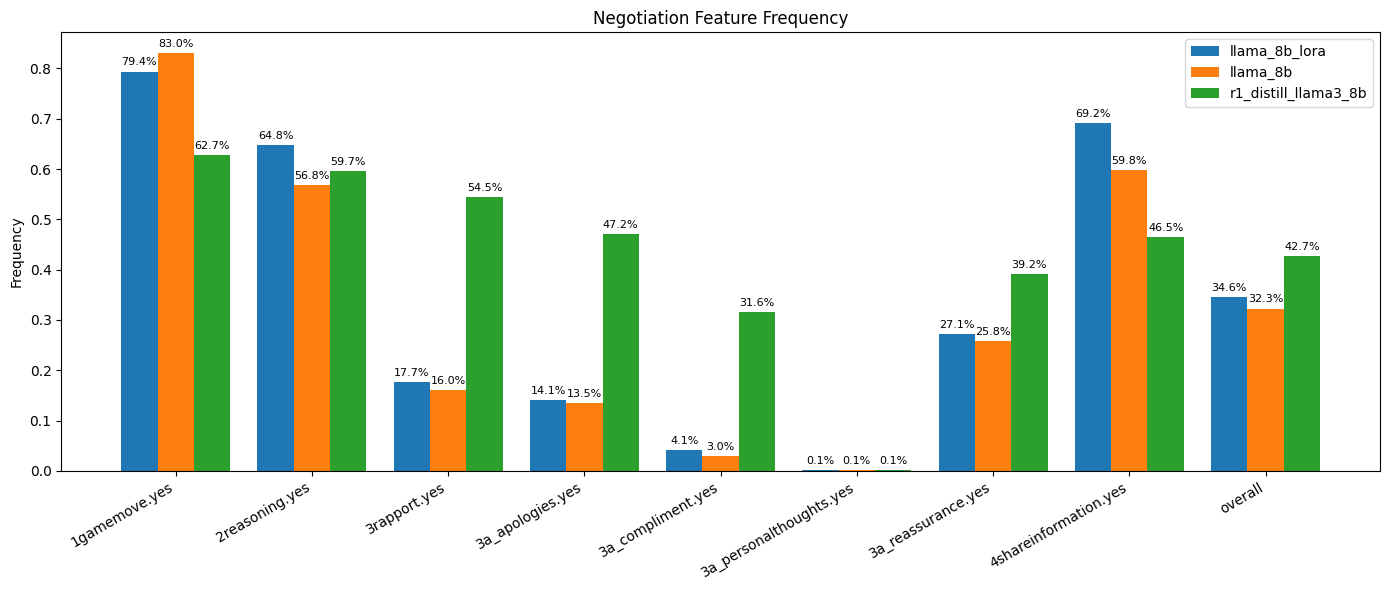

In [19]:
# 计算不同models的negotiation features出现的频率，并画图
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

features = [
    '1gamemove.yes',
    '2reasoning.yes',
    '3rapport.yes',
    '3a_apologies.yes',
    '3a_compliment.yes',
    '3a_personalthoughts.yes',
    '3a_reassurance.yes',
    '4shareinformation.yes'
]

def clean_model_name(name):
    # 去掉finetune及其后所有内容，包括前面的下划线
    m = re.match(r"(.+?)(?:_finetune.*)?$", name)
    if m:
        return m.group(1)
    return name

# 只保留不包含qwen的model
filtered_model_feature_ratios = {}

for model_name, data_list in v6_data_dict.items():
    if not data_list:
        continue
    cleaned_name = clean_model_name(model_name)
    if 'qwen' not in cleaned_name.lower():
        df = pd.DataFrame(data_list)
        for feat in features:
            if feat not in df.columns:
                df[feat] = 0
        ratios = []
        for feat in features:
            ratios.append(df[feat].fillna(0).astype(int).mean())
        # 计算overall: 该model所有features的平均
        overall = np.mean(ratios)
        ratios_with_overall = ratios + [overall]
        filtered_model_feature_ratios[cleaned_name] = ratios_with_overall

# 新的features list，最后加一个overall
features_with_overall = features + ['overall']

# 画图
x = np.arange(len(features_with_overall))
width = 0.8 / max(1, len(filtered_model_feature_ratios))  # 动态调整宽度

fig, ax = plt.subplots(figsize=(14, 6))

for idx, (model_name, ratios) in enumerate(filtered_model_feature_ratios.items()):
    rects = ax.bar(x + (idx - len(filtered_model_feature_ratios)/2)*width + width/2, ratios, width, label=model_name)
    # 在柱子上标注百分比
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{:.1f}%'.format(height * 100),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Frequency')
ax.set_title('Negotiation Feature Frequency')
ax.set_xticks(x)
ax.set_xticklabels(features_with_overall, rotation=30, ha='right')
ax.legend()
plt.tight_layout()
plt.show()